# Упражнение 2.11. Параметрическое исследование для нестационарного случая

Саттон, Барто, «Обучение с подкреплением».
Полный разбор — в сборнике решений: [глава 2 (PDF)](https://michaeltoschenko.github.io/RL_Sutton_Barto_Solutions/ch02.pdf).


In [70]:
import matplotlib.pyplot as plt
import random
import numpy as np
from tqdm import tqdm

In [71]:
K = 10
N_STEPS = 200000
N_AVERAGE = 100000
N_TASKS = 100
EPS_RANGE = (1/128) * 2 ** np.arange(7)
UCB_RANGE = (1/128) * 2 ** np.arange(10)
GRAD_RANGE = (1/128) * 2 ** np.arange(10)
OPT_RANGE = (1/4) * 2 ** np.arange(7)

In [72]:
def run_solution(k, n_tasks, n_steps, n_average, algorithm, val_range):
    """
    eps - eps-жадный, меняем alpha
    ucb - ВДГ, меняем c
    optimistic_init - жадный с оптимистической инициализацией, меняем Q_0
    gradient - градиентный бандит, меняем alpha
    """
    if algorithm not in ("eps", "ucb", "optimistic_init", "gradient"):
        raise ValueError("Unknown algorithm")

    res = []
    for task in tqdm(range(n_tasks), desc="Tasks"):
        task_res = []
        for val in val_range:
            values_true_mu = np.zeros(k)
            if algorithm == "optimistic_init":
                values_est = np.full(k, val)
            else:
                values_est = np.zeros(k)
            count = np.zeros(k)
            baseline = 0
            rewards = []
            for step in range(n_steps):
                if algorithm == "eps":
                    if np.random.uniform() > 0.1:
                        max_q = np.max(values_est)
                        greedy_actions = np.flatnonzero(values_est == max_q)
                        action = np.random.choice(greedy_actions)
                    else:
                        action = np.random.randint(0, k)
                    reward = np.random.normal(values_true_mu[action], 1)
                    rewards.append(reward)
                    values_est[action] = values_est[action] + val*(reward - values_est[action])
                elif algorithm == "ucb":
                    zero_actions = np.flatnonzero(count == 0)
                    if len(zero_actions) > 0:
                        action = np.random.choice(zero_actions)
                    else:
                        tmp = values_est + val*(np.log(step)/count)**0.5
                        max_tmp = np.max(tmp)
                        optimal_actions = np.flatnonzero(tmp == max_tmp)
                        action = np.random.choice(optimal_actions)
                    count[action] += 1
                    reward = np.random.normal(values_true_mu[action], 1)
                    rewards.append(reward)
                    values_est[action] = values_est[action] + 0.1*(reward - values_est[action])
                elif algorithm == "optimistic_init":
                    max_q = np.max(values_est)
                    greedy_actions = np.flatnonzero(values_est == max_q)
                    action = np.random.choice(greedy_actions)
                    reward = np.random.normal(values_true_mu[action], 1)
                    rewards.append(reward)
                    values_est[action] = values_est[action] + 0.1*(reward - values_est[action])
                elif algorithm == "gradient":
                    exp = np.exp(values_est - np.max(values_est))
                    softmax = exp / np.sum(exp)
                    action = np.random.choice(k, p=softmax)
                    reward = np.random.normal(values_true_mu[action], 1)
                    rewards.append(reward)
                    baseline += 1/(step+1)*(reward - baseline)
    
                    one_hot = np.zeros_like(values_est)
                    one_hot[action] = 1.0
    
                    values_est += val*(reward - baseline)*(one_hot - softmax)
                values_true_mu += np.random.normal(0, 0.01, k)
            task_res.append(np.mean(rewards[-n_average:]))
        res.append(task_res)
            
    return np.mean(res, axis=0)

In [73]:
eps_res = run_solution(K, N_TASKS, N_STEPS, N_AVERAGE, 'eps', EPS_RANGE)
ucb_res = run_solution(K, N_TASKS, N_STEPS, N_AVERAGE, 'ucb',  UCB_RANGE)
optimistic_res = run_solution(K, N_TASKS, N_STEPS, N_AVERAGE, 'optimistic_init', OPT_RANGE)
gradient_res = run_solution(K, N_TASKS, N_STEPS, N_AVERAGE, 'gradient', GRAD_RANGE)

Tasks:   0%|          | 0/100 [00:00<?, ?it/s]

Tasks:   0%|          | 0/100 [00:00<?, ?it/s]

Tasks:   0%|          | 0/100 [00:00<?, ?it/s]

Tasks:   0%|          | 0/100 [00:00<?, ?it/s]

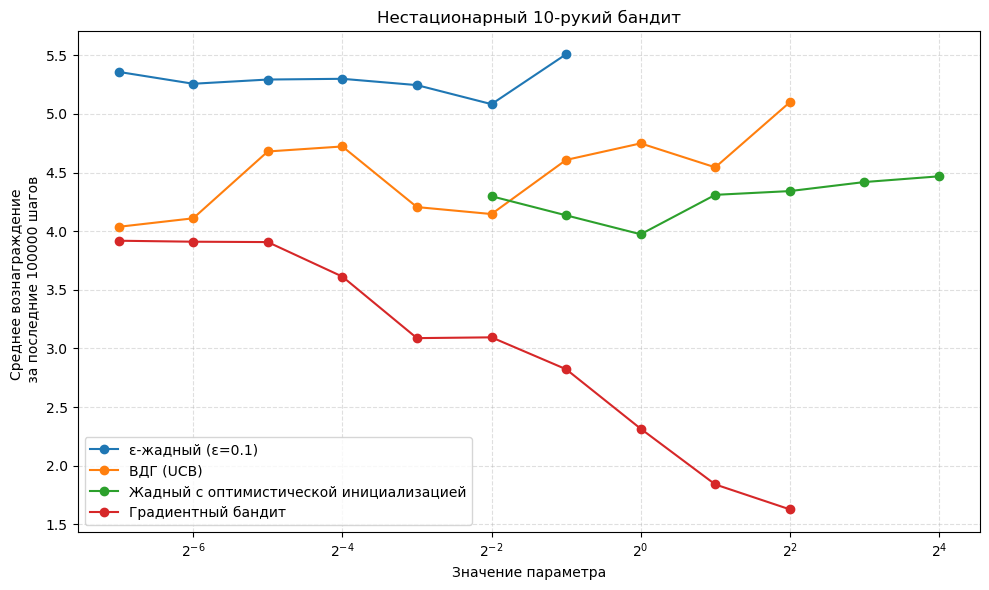

In [74]:
plt.figure(figsize=(10, 6))

plt.plot(EPS_RANGE, eps_res, marker='o', label='ε-жадный (ε=0.1)')
plt.plot(UCB_RANGE, ucb_res, marker='o', label='ВДГ (UCB)')
plt.plot(OPT_RANGE, optimistic_res, marker='o', label='Жадный с оптимистической инициализацией')
plt.plot(GRAD_RANGE, gradient_res, marker='o', label='Градиентный бандит')

plt.xscale('log', base=2)

plt.xlabel('Значение параметра')
plt.ylabel(f'Среднее вознаграждение \n за последние {N_AVERAGE} шагов')
plt.title(f'Нестационарный {K}-рукий бандит')

plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()